# Marketing Channel Performance

**Author: Tajamul Khan**

Which channels deserve further budget experiments?

Original synthetic teaching data. All outputs below are calculated by executing these cells. This is an analytical portfolio case study, not a real client engagement.

## Situation and task

A marketing team compares platform totals without consistent cost and attribution definitions.

Compare attributed revenue, acquisition cost and return on advertising spend.

## Data contract and KPI definitions

Grain is channel-day; CVR = conversions / clicks; CAC = spend / attributed new customers; ROAS = attributed revenue / spend. Aggregate numerators and denominators before calculating rates. All money is USD.

See `data/README.md` for field types, source and seed.

In [1]:
from pathlib import Path
import json, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
BASE = Path.cwd()
assert (BASE/'data/raw.csv').exists(), 'Run from this project directory'
OUT = BASE/'outputs'
OUT.mkdir(exist_ok=True)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})
df = pd.read_csv(BASE/'data/raw.csv')
if 'date' in df:
    df['date'] = pd.to_datetime(df['date'])
print('Raw shape:',df.shape)
display(df.head())


Raw shape: (1460, 7)


,date,channel,clicks,conversions,new_customers,spend,attributed_revenue
0,2025-01-01,Search,374,17,13,469.59,1212.59
1,2025-01-01,Social,423,15,10,282.43,1011.87
2,2025-01-01,Email,220,5,3,215.67,307.75
3,2025-01-01,Display,106,1,0,57.08,65.17
4,2025-01-02,Search,338,12,8,164.00,782.66


## Validate the source

Inspect missingness and grain before computing metrics. Missing outcomes are not automatically zeros.

In [2]:
audit=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing':df.isna().sum(),'unique_values':df.nunique()})
display(audit)
print('Exact duplicate rows:',df.duplicated().sum())
audit.to_csv(OUT/'data_quality.csv')


Exact duplicate rows: 0


,dtype,missing,unique_values
date,datetime64[ns],0,365
channel,object,0,4
clicks,int64,0,391
conversions,int64,0,41
new_customers,int64,0,29
spend,float64,0,1440
attributed_revenue,float64,0,1437


## Action: analysis

Aggregate spend and outcomes before division, reconcile channel totals and distinguish attribution from incrementality.

In [3]:
assert not df.duplicated(['date','channel']).any()
assert (df.conversions<=df.clicks).all() and (df.new_customers<=df.conversions).all()
summary=df.groupby('channel')[['clicks','conversions','new_customers','spend','attributed_revenue']].sum()
summary['cvr_pct']=100*summary.conversions/summary.clicks
summary['cac']=summary.spend/summary.new_customers.replace(0,np.nan)
summary['roas']=summary.attributed_revenue/summary.spend
metrics={'Spend (USD)':df.spend.sum(),'Attributed ROAS':df.attributed_revenue.sum()/df.spend.sum(),'Attributed CAC (USD)':df.spend.sum()/df.new_customers.sum()}
chart=summary.roas; ylabel='Attributed revenue / spend'

## Deep dive: Monthly ROAS stability

Evaluate monthly ratios from summed numerators and denominators. A channel annual average can hide variation.

Email has the highest annual attributed ROAS (4.92). Test incremental lift before moving budget because attribution alone cannot establish profitability.
Out[4]: 154


channel,Display,Email,Search,Social
date,,,,
2025-01,0.993,4.916,3.578,1.877
2025-02,1.120,4.905,3.440,2.258
2025-03,1.221,4.984,3.049,1.880
2025-04,1.170,5.024,3.319,1.579
2025-05,1.041,5.020,3.524,2.078
2025-06,1.422,4.054,2.747,2.045
2025-07,1.058,5.537,4.017,2.185
2025-08,1.069,6.265,3.554,2.262
2025-09,1.152,4.525,3.706,2.209


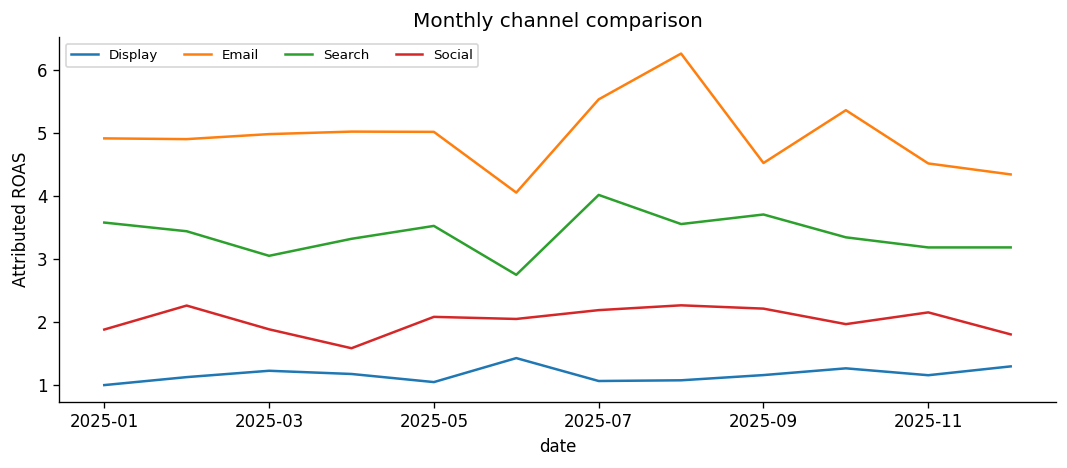

In [4]:

detail=df.groupby([df.date.dt.to_period('M').astype(str),'channel'])[['spend','attributed_revenue']].sum();detail['roas']=detail.attributed_revenue/detail.spend
detail=detail.roas.unstack('channel');display(detail.round(3))
fig,ax=plt.subplots(figsize=(9,4));detail.plot(ax=ax);ax.set_ylabel('Attributed ROAS');ax.set_title('Monthly channel comparison');ax.legend(ncol=4,fontsize=8);fig.tight_layout();fig.savefig(OUT/'detail.png');plt.show()
best=summary.roas.idxmax()
recommendation=f'{best} has the highest annual attributed ROAS ({summary.loc[best,"roas"]:.2f}). Test incremental lift before moving budget because attribution alone cannot establish profitability.'

detail.to_csv(OUT/'detail.csv')
print(recommendation)
(OUT/'recommendation.txt').write_text(recommendation+'\n')


## Results: calculated evidence

These describe only the included synthetic dataset. They do not measure deployed impact.

In [5]:
display(summary.round(4))
display(pd.Series(metrics,name='value').to_frame())
summary.to_csv(OUT/'summary.csv')
(OUT/'metrics.json').write_text(json.dumps({k:float(v) for k,v in metrics.items()},indent=2))
df.to_csv(OUT/'analysis_ready.csv',index=False)
assert all(np.isfinite(float(v)) for v in metrics.values()), 'Invalid KPI'


,clicks,conversions,new_customers,spend,attributed_revenue,cvr_pct,cac,roas
channel,,,,,,,,
Display,106155,1555,1040,94078.20,108992.77,1.4648,90.4598,1.1585
Email,108487,6549,4265,93798.10,461224.82,6.0367,21.9925,4.9172
Search,112826,4940,3217,103348.36,348485.24,4.3784,32.1257,3.3719
Social,109611,2798,1860,97083.35,195933.34,2.5527,52.1953,2.0182


,value
Spend (USD),388308.010000
Attributed ROAS,2.870495
Attributed CAC (USD),37.402043


## SQL cross-check

Load validated facts into SQLite and reconcile shared aggregates against Python.

In [6]:
with sqlite3.connect(':memory:') as conn:
    df.to_sql('facts',conn,index=False,if_exists='replace')
    sql_result=pd.read_sql_query((BASE/'analysis.sql').read_text(),conn)
display(sql_result)
sql_result.to_csv(OUT/'sql_results.csv',index=False)
# Reconcile at least one common aggregate by group, rather than trusting the SQL output.
key=sql_result.columns[0]
py=summary.reset_index()
common=[c for c in sql_result.columns[1:] if c in py.columns]
assert common, 'No comparable aggregate'
joined=sql_result.merge(py,on=key,suffixes=('_sql','_python'),validate='one_to_one')
assert len(joined)==len(summary)==len(sql_result)
for col in common:
    assert np.allclose(joined[col+'_sql'],joined[col+'_python'],rtol=1e-8,atol=1e-6), col
print('SQL / Python reconciliation passed:',common)


SQL / Python reconciliation passed: ['spend', 'roas']


,channel,spend,roas
0,Display,94078.20,1.158534
1,Email,93798.10,4.917209
2,Search,103348.36,3.371947
3,Social,97083.35,2.018197


## Visual interpretation

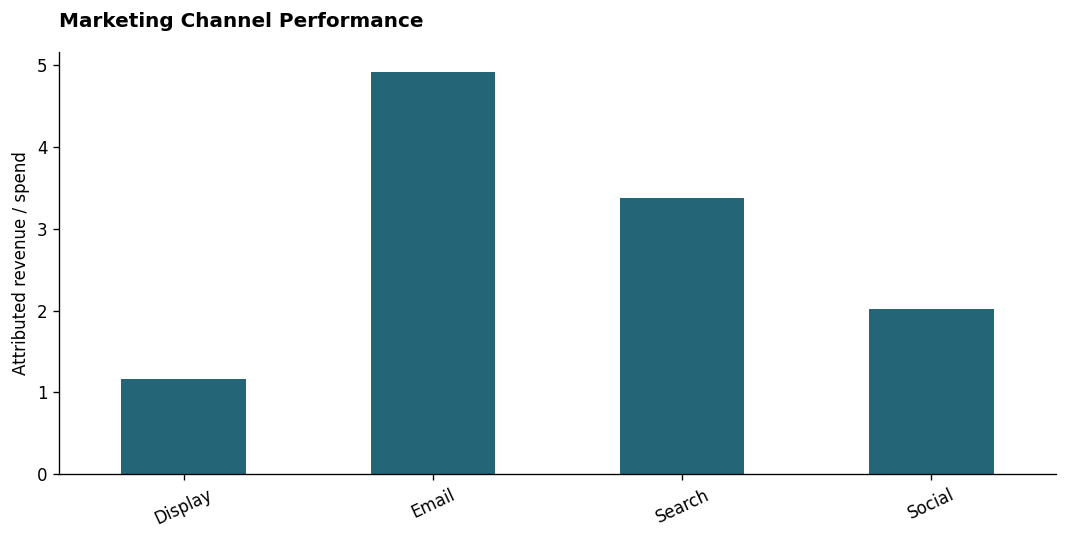

In [7]:
fig,ax=plt.subplots(figsize=(9,4.6))
chart.plot(kind='bar',ax=ax,color='#246577',rot=25)
ax.set_ylabel(ylabel)
ax.set_xlabel('')
ax.set_title('Marketing Channel Performance',loc='left',fontweight='bold',pad=15)
fig.tight_layout()
fig.savefig(OUT/'overview.png',bbox_inches='tight')
plt.show()


## Offline dashboard

The KPI cards and chart are a fixed analysis snapshot. The row filter searches the summary table; it does not recompute the KPIs.

In [8]:
# Standalone dashboard: no remote JavaScript, server or account required.
import html, base64
cards=''.join('<article><span>'+html.escape(k)+'</span><strong>'+f'{v:,.4f}'+'</strong></article>' for k,v in metrics.items())
image=base64.b64encode((OUT/'overview.png').read_bytes()).decode()
table=summary.round(4).to_html(classes='data',border=0)
page='''<!doctype html><html lang="en"><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1"><title>Marketing Channel Performance</title>
<style>body{font:16px system-ui;margin:0;background:#f3f5f7;color:#172c3b}main{max-width:1100px;margin:auto;padding:36px}header{border-bottom:3px solid #246577;margin-bottom:24px}small{color:#51616c}.cards{display:flex;gap:14px;flex-wrap:wrap}article{background:white;padding:18px;border:1px solid #d7e0e5;flex:1;min-width:175px}strong{display:block;font-size:27px;margin-top:12px}img{max-width:100%;margin-top:24px}table{border-collapse:collapse;background:white;width:100%;font-size:14px}td,th{padding:12px;text-align:right;border-bottom:1px solid #d7e0e5}input{padding:12px;margin:20px 0;width:280px;max-width:90%}.scroll{overflow:auto}footer{margin-top:24px}</style>
<main><header><small>TAJAMUL KHAN · DATA ANALYST PORTFOLIO</small><h1>Marketing Channel Performance</h1><p>Which channels deserve further budget experiments?</p><p><b>Synthetic teaching data · Fictional 2025 case study</b></p></header><section class="cards">'''+cards+'''</section><img alt="Analysis overview chart" src="data:image/png;base64,'''+image+'''"><h2>Explore summary groups</h2><label for="filter">Filter summary rows</label><br><input id="filter" placeholder="Type a group name"><div class="scroll">'''+table+'''</div><p>Last-touch attribution is a simulation assumption. ROAS excludes margin and is not incremental ROI. New customers are deduplicated within each channel-day only.</p><footer>Instagram @tajamul.codes · linkedin.com/in/tajamulkhann/</footer></main>
<script>document.getElementById('filter').addEventListener('input',function(){const q=this.value.toLowerCase();document.querySelectorAll('tbody tr').forEach(r=>r.hidden=!r.textContent.toLowerCase().includes(q))});</script></html>'''
detail_image=base64.b64encode((OUT/'detail.png').read_bytes()).decode()
page=page.replace('<h2>Explore summary groups</h2>','<h2>Analyst finding</h2><p>'+html.escape(recommendation)+'</p><img alt="Supporting analysis" src="data:image/png;base64,'+detail_image+'"><h2>Explore summary groups</h2>')
(OUT/'dashboard.html').write_text(page)
print('Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.')


Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.


## Decision, limitations and next step

Last-touch attribution is a simulation assumption. ROAS excludes margin and is not incremental ROI. New customers are deduplicated within each channel-day only.

**Next step:** Use customer-level deduplication and a geographic or user-level lift experiment.

Use the result table to identify a priority for investigation. Avoid claiming that the suggested action has already delivered a business improvement.

## Career discussion

Explain the business question, data grain, denominator, validation, strongest finding and one limitation. Use the README STAR story only after reproducing and understanding this project.